# Lab 7- Data Analysis

Exercises 1-4 are to be completed by October 25th. The remaider of the lab is due November 1st. Before leaving lab today, everyone must download the dataset.

## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [8]:
!curl -L http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz -o SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1446k    0 1446k    0     0  1649k      0 --:--:-- --:--:-- --:--:-- 1649k
100 5742k    0 5742k    0     0  3061k      0 --:--:--  0:00:01 --:--:-- 3061k
100 12.4M    0 12.4M    0     0  4423k      0 --:--:--  0:00:02 --:--:-- 4423k
100 20.5M    0 20.5M    0     0  5434k      0 --:--:--  0:00:03 --:--:-- 5434k
100 28.2M    0 28.2M    0     0  5932k      0 --:--:--  0:00:04 --:--:-- 5933k
100 35.6M    0 35.6M    0     0  6217k      0 --:--:--  0:00:05 --:--:-- 7016k
100 43.3M    0 43.3M    0     0  6457k      0 --:--:--  0:00:06 --:--:-- 7732k
100 51.0M    0 51.0M    0     0  6639k      0 --:--:--  0:00:07 --:--:-- 7914k
100 58.5M    0 58.5M    0     0  6751k      0 --:--:--  0:00:08 --:--:-- 7773k
100 66.2M    0 66.2M    0     0  6871k      0 --:--

In [9]:
import gzip, shutil

with gzip.open('SUSY.csv.gz', 'rb') as f_in:
    with open('SUSY.csv', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

In [24]:
import pandas as pd

chunk = pd.read_csv("SUSY.csv", nrows=500000, header=None)
chunk.to_csv("SUSY-small.csv", index=False, header=False)

In [25]:
import pandas as pd
df = pd.read_csv("SUSY-small.csv", header=None)
df.shape

(500000, 19)

In [26]:
df.iloc[0] #i'm supposed to have 18. but it read 19. this is just for clarification.

0     0.000000
1     0.972861
2     0.653855
3     1.176225
4     1.157156
5    -1.739873
6    -0.874309
7     0.567765
8    -0.175000
9     0.810061
10   -0.252552
11    1.921887
12    0.889637
13    0.410772
14    1.145621
15    1.932632
16    0.994464
17    1.367815
18    0.040714
Name: 0, dtype: float64

The data is provided as a comma separated file.

In [12]:
import pandas as pd

pd.read_csv("SUSY.csv", nrows=5, header=None)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859


## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [13]:
import os

for f in os.listdir():
    print(f, round(os.path.getsize(f)/1e6, 2), "MB")

.ipynb_checkpoints 0.0 MB
Lab.7.ipynb 0.4 MB
Lab.7.pdf 6.12 MB
SUSY-small.csv 0.0 MB
SUSY.csv 2390.28 MB
SUSY.csv.gz 922.38 MB


We see that we have 5 million datapoints.

In [14]:
sum(1 for _ in open("SUSY.csv"))

5000000

We create a new file of the first half million. This is sufficient for our needs in this lab:

In [20]:
import pandas as pd

chunk = pd.read_csv("SUSY.csv", nrows=500000, header=None)
chunk.to_csv("SUSY-small.csv", index=False, header=False)

In [21]:
import os

for f in os.listdir():
    print(f, round(os.path.getsize(f)/1e6, 2), "MB")

.ipynb_checkpoints 0.0 MB
Lab.7.ipynb 0.41 MB
Lab.7.pdf 6.12 MB
SUSY-small.csv 173.45 MB
SUSY.csv 2390.28 MB
SUSY.csv.gz 922.38 MB


In [23]:
sum(1 for _ in open("SUSY-small.csv"))

500000

Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [43]:
VarNames = [
    "signal",
    "l_1_pT",
    "l_1_eta",
    "l_1_phi",
    "l_2_pT",
    "l_2_eta",
    "l_2_phi",
    "MET",
    "MET_phi",
    "MET_rel",
    "axial_MET",
    "M_R",
    "M_TR_2",
    "R",
    "MT2",
    "S_R",
    "M_Delta_R",
    "dPhi_r_b",
    "cos_theta_r1"
]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [44]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [45]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [46]:
FeatureNames

['MET_rel',
 'M_R',
 'cos_theta_r1',
 'axial_MET',
 'R',
 'M_TR_2',
 'M_Delta_R',
 'MT2',
 'dPhi_r_b',
 'S_R']

In [47]:
print(len(VarNames))
print(VarNames)

19
['signal', 'l_1_pT', 'l_1_eta', 'l_1_phi', 'l_2_pT', 'l_2_eta', 'l_2_phi', 'MET', 'MET_phi', 'MET_rel', 'axial_MET', 'M_R', 'M_TR_2', 'R', 'MT2', 'S_R', 'M_Delta_R', 'dPhi_r_b', 'cos_theta_r1']


We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [52]:
filename = "SUSY-small.csv"
df = pd.read_csv(filename, header=None, usecols=range(19))
df.columns = VarNames
df.shape

(500000, 19)

You can see the data in Jupyter by just evaluateing the dataframe:

In [50]:
df.shape

(5000000, 19)

The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [53]:
df_sig = df[df.signal == 1]
df_bkg = df[df.signal == 0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


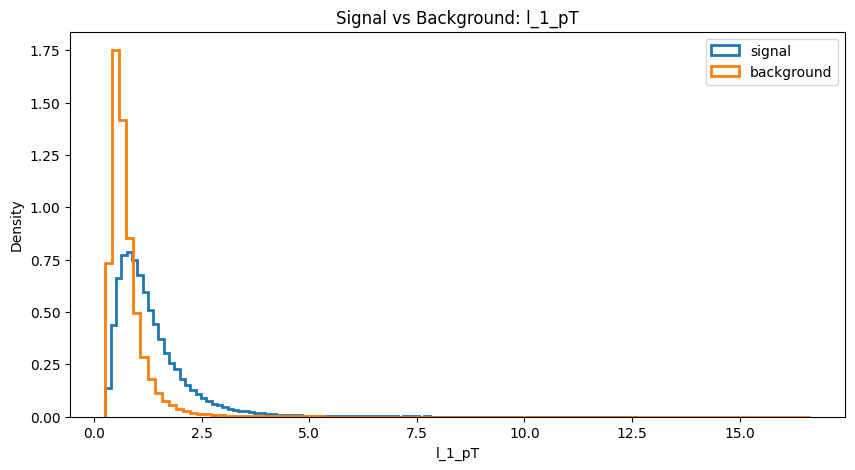

l_1_eta


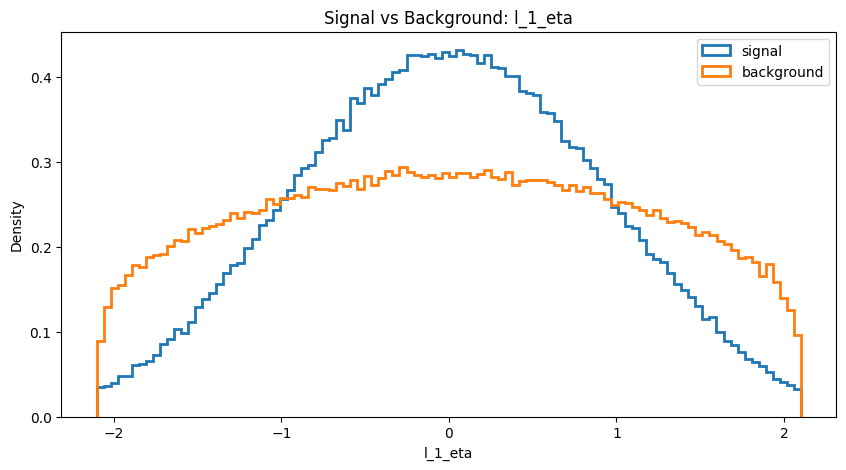

l_1_phi


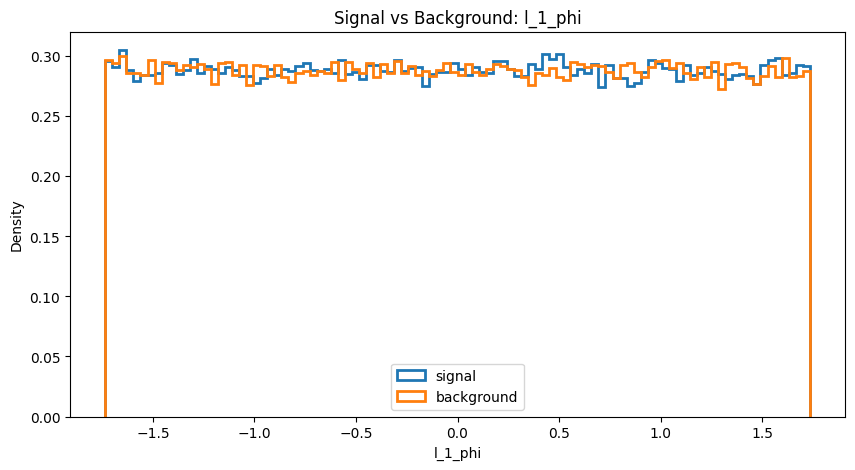

l_2_pT


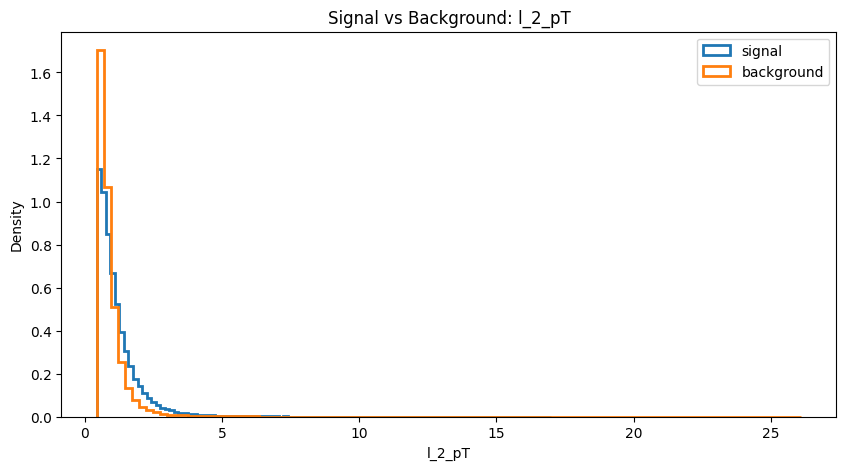

l_2_eta


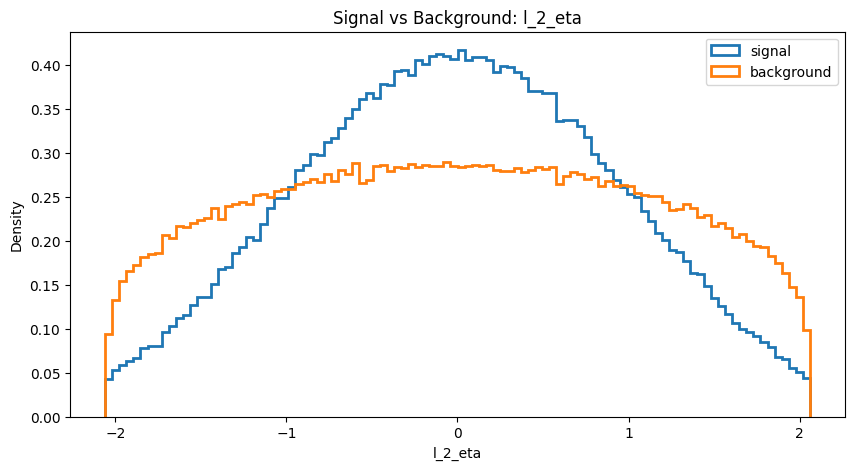

l_2_phi


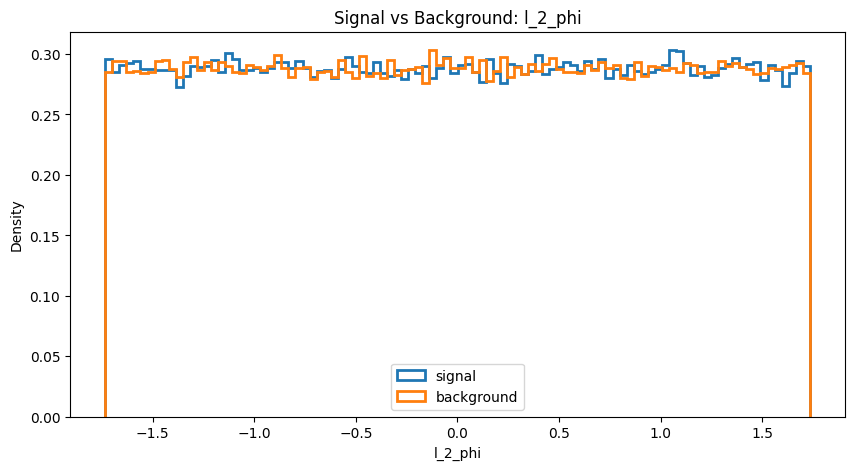

MET


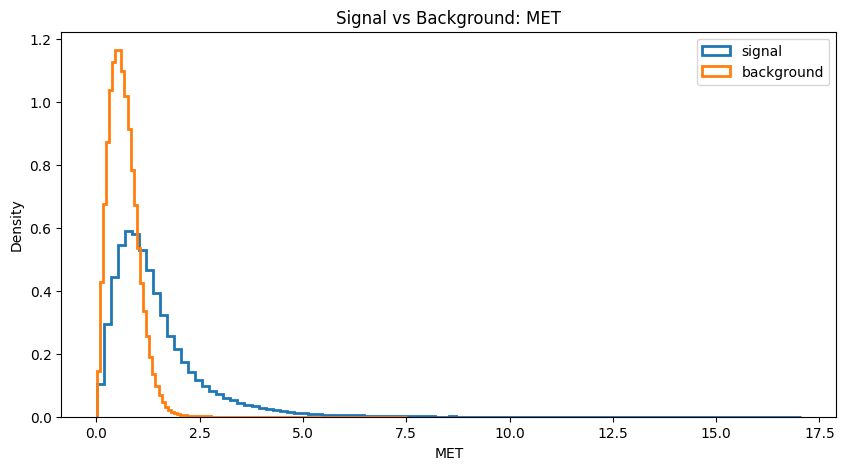

MET_phi


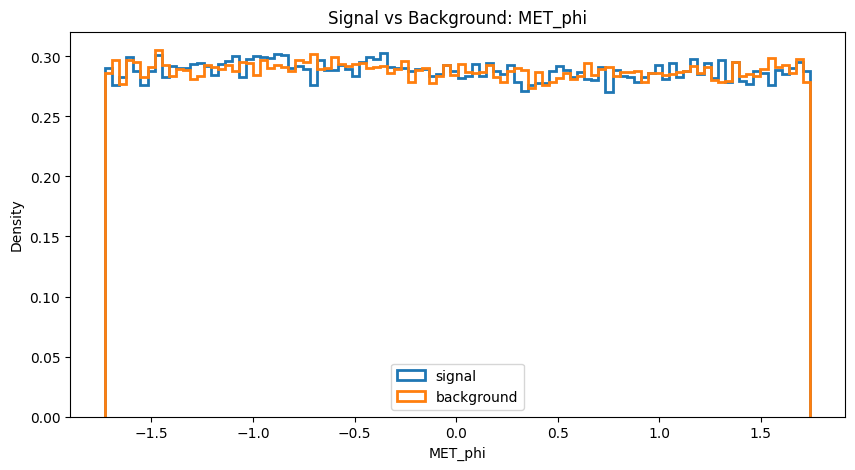

MET_rel


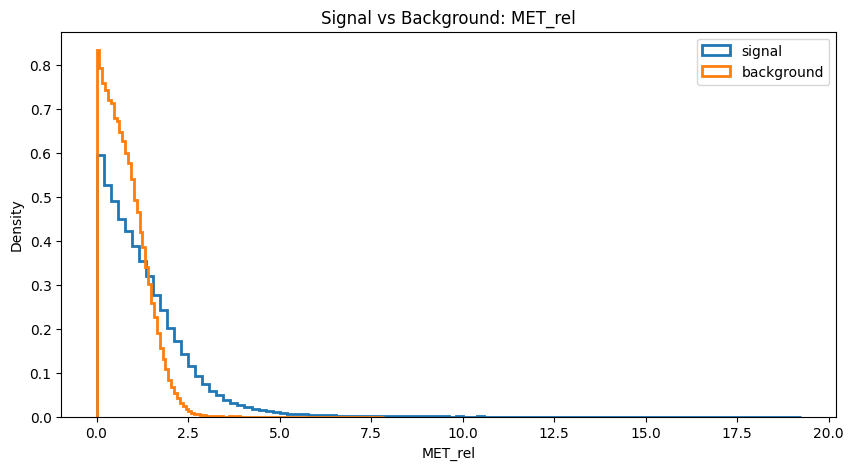

axial_MET


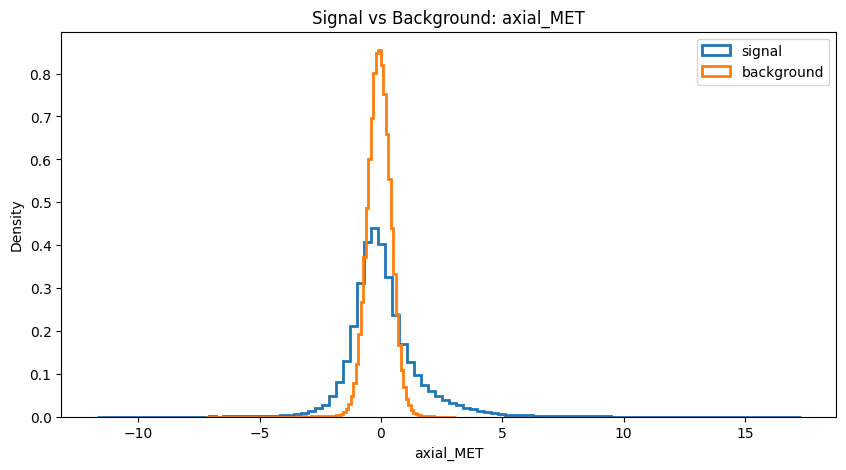

M_R


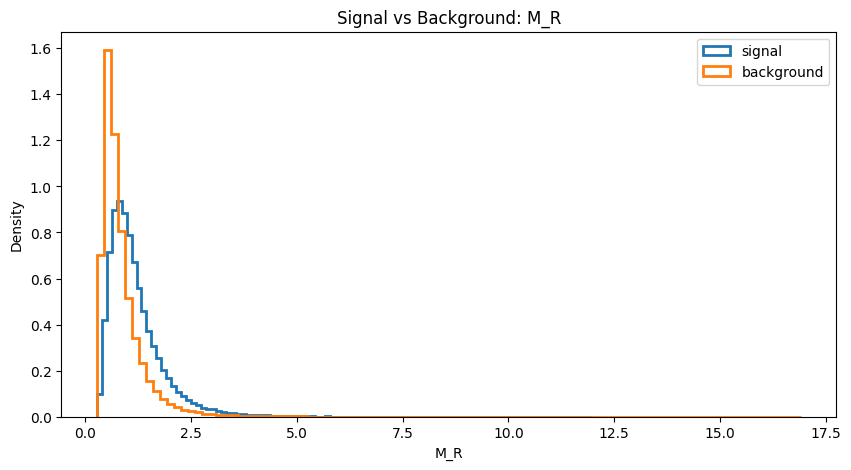

M_TR_2


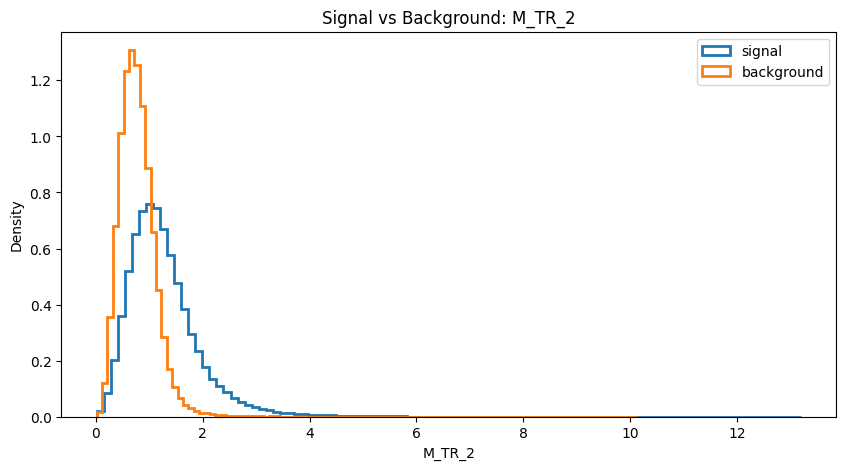

R


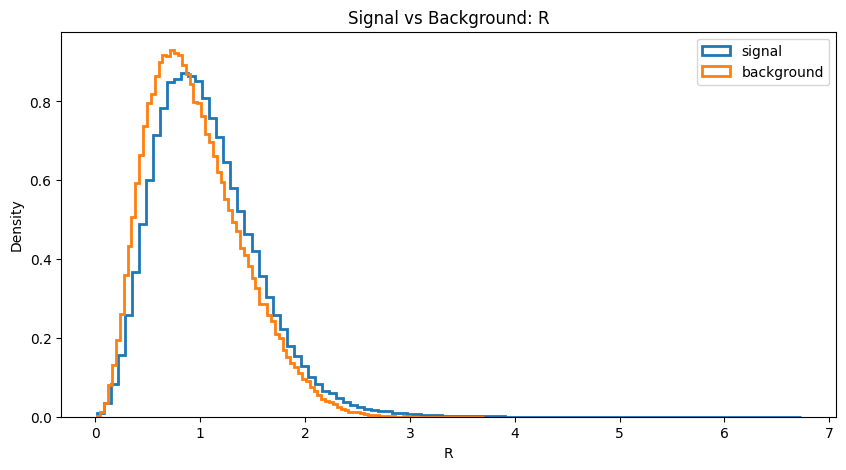

MT2


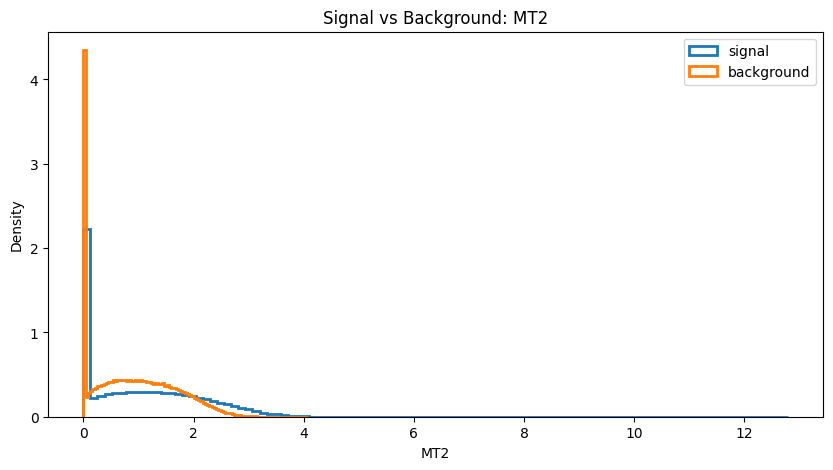

S_R


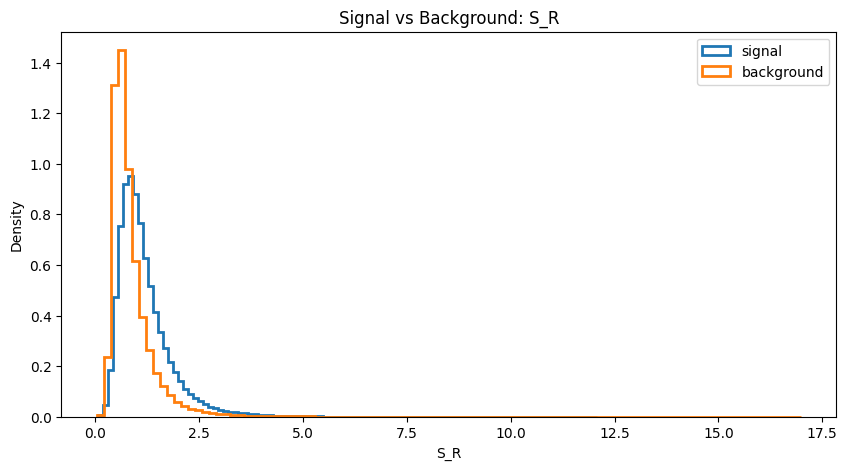

M_Delta_R


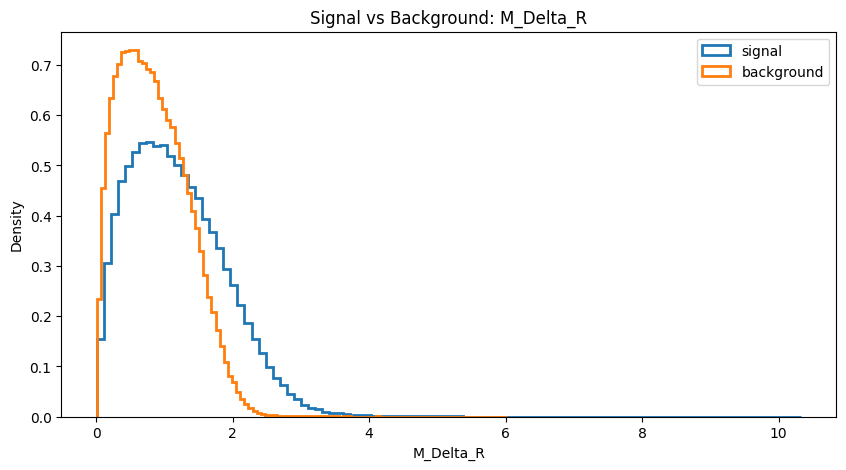

dPhi_r_b


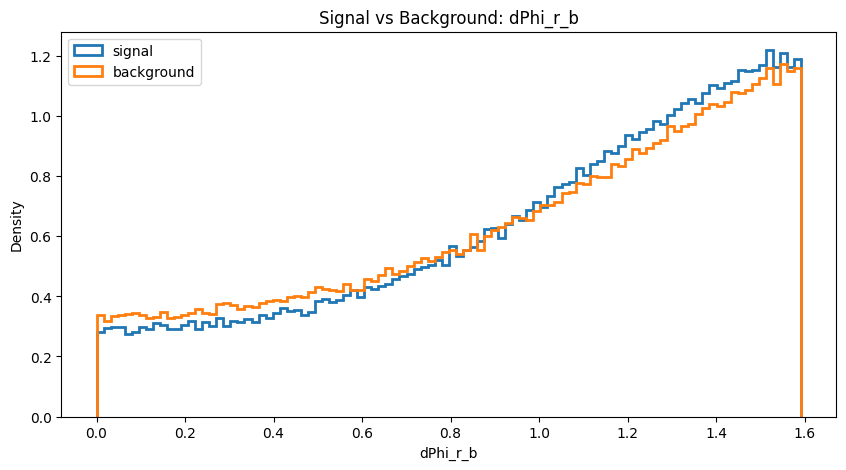

cos_theta_r1


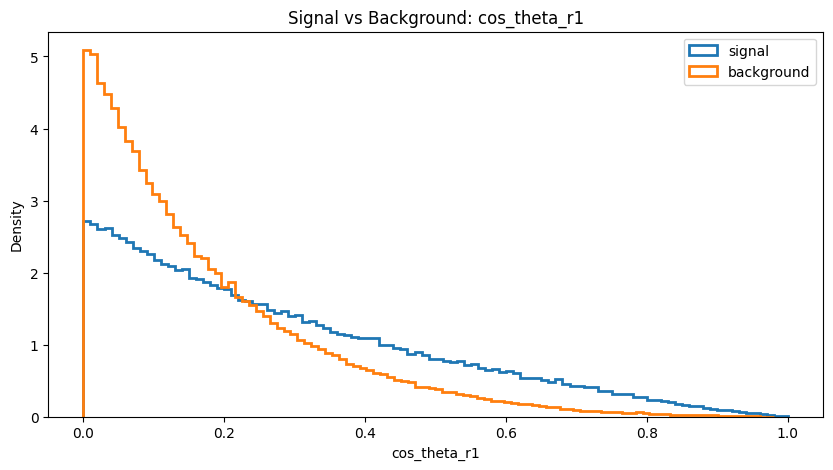

In [54]:
for var in VarNames[1:]:
    print(var)
    plt.figure(figsize=(10,5))
    plt.hist(df_sig[var], bins=100, density=True, histtype="step", linewidth=2, label="signal")
    plt.hist(df_bkg[var], bins=100, density=True, histtype="step", linewidth=2, label="background")
    plt.xlabel(var)
    plt.ylabel("Density")
    plt.title(f"Signal vs Background: {var}")
    plt.legend()
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

In [57]:
def nice_hist_grid(df_sig, df_bkg, variables, cols=3):
    import matplotlib.pyplot as plt
    import math

    rows = math.ceil(len(variables) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axes = axes.flatten()

    for i, var in enumerate(variables):
        ax = axes[i]

        ax.hist(df_sig[var], bins=80, density=True,
                histtype="step", linewidth=2, label="signal")
        ax.hist(df_bkg[var], bins=80, density=True,
                histtype="step", linewidth=2, label="background")

        ax.set_title(var)
        ax.set_xlabel(var)
        ax.set_ylabel("Density")
        ax.legend()

    # remove empty plots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

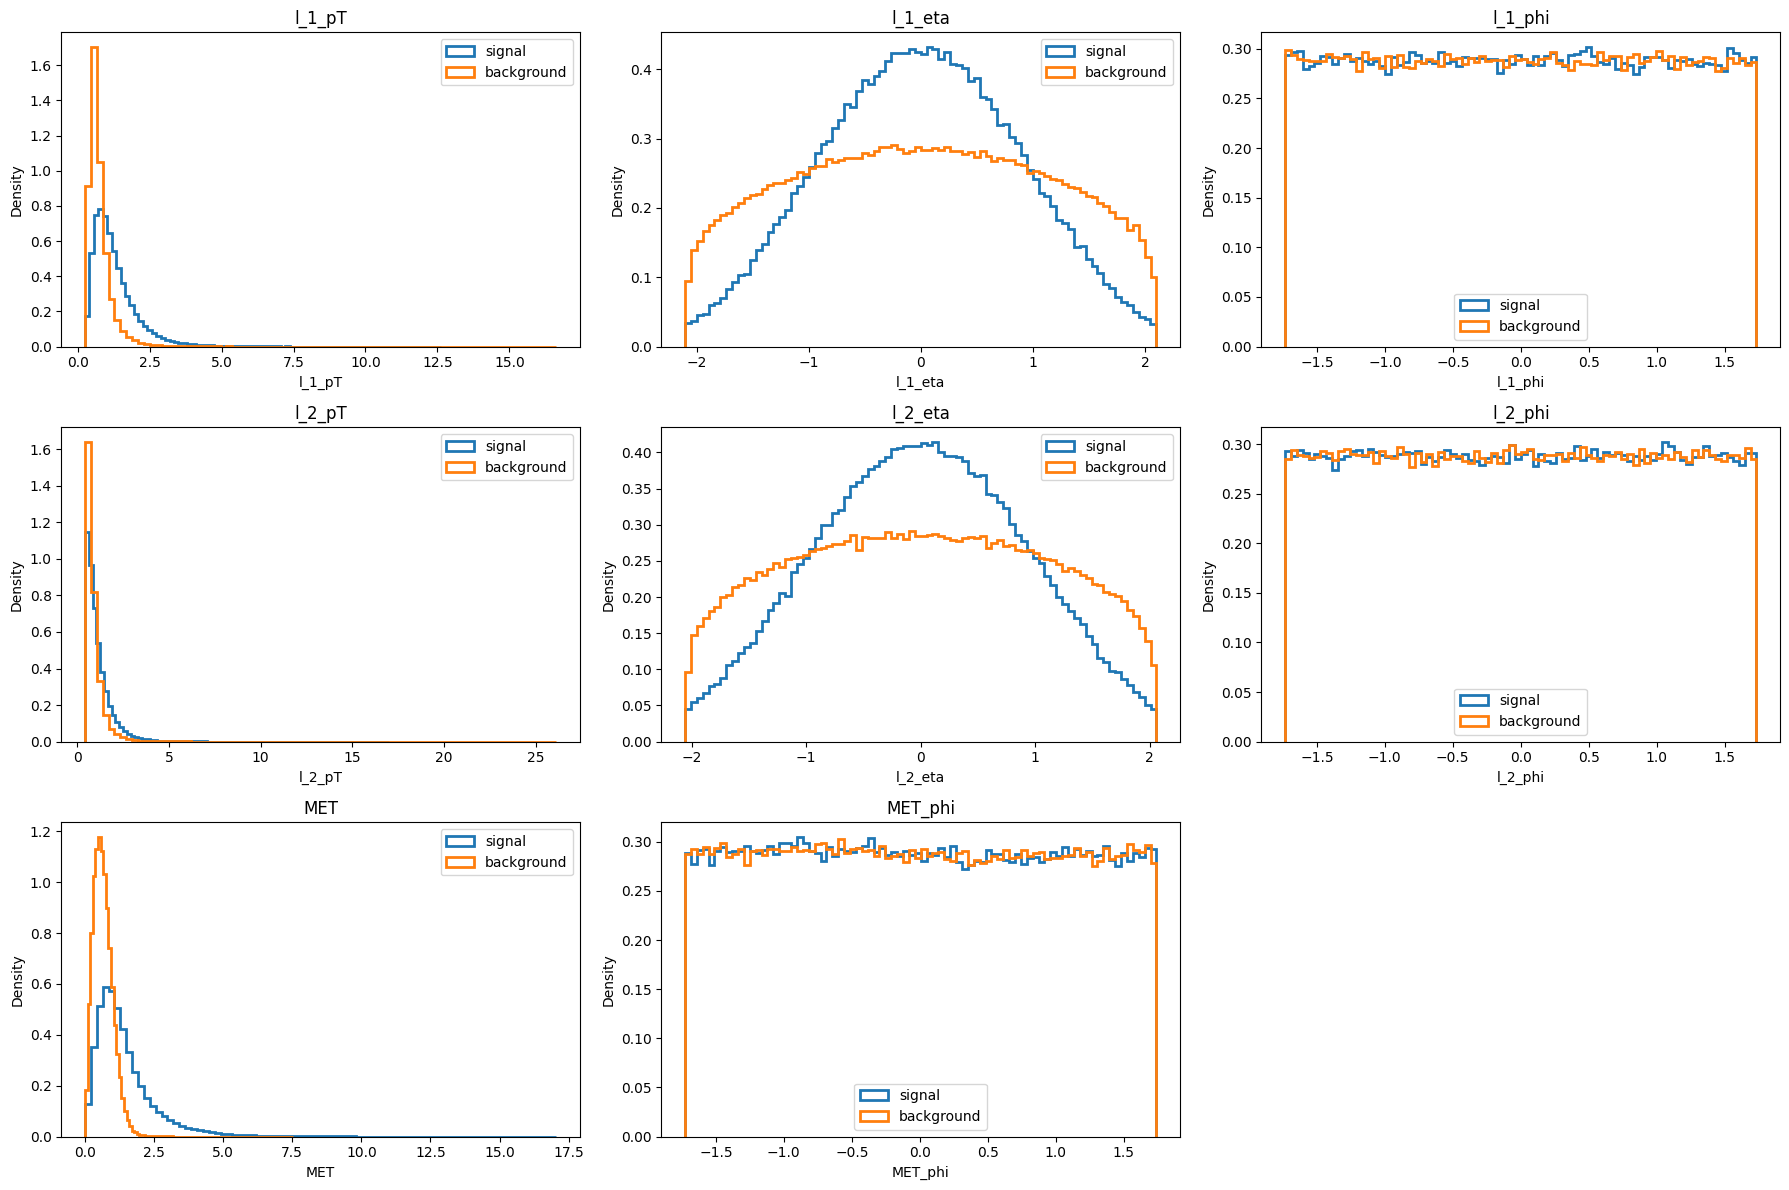

In [58]:
nice_hist_grid(df_sig, df_bkg, RawNames, cols=3)

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

In [ ]:
# Would be High level engineered variables such as MET_rel, axial_MET, M_R, M_TR_2, R, and MT2 show the strongest separation between signal and background distributions. So in contrast, low-level kinematic variables (η and φ components) exhibit significant overlap and provide weaker discriminative power.

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [59]:
!pip install tabulate

Hint: Example code for embedding a `tabulate` table into a notebook:

In [72]:
import numpy as np
data_all = df.iloc[:, 1:]

cov_all = np.cov(data_all, rowvar=False)
corr_all = np.corrcoef(data_all, rowvar=False)
cov_raw = np.cov(df[RawNames], rowvar=False)
corr_raw = np.corrcoef(df[RawNames], rowvar=False)
cov_feat = np.cov(df[FeatureNames], rowvar=False)
corr_feat = np.corrcoef(df[FeatureNames], rowvar=False)

In [73]:
from IPython.display import HTML, display
import tabulate

def show_table(matrix, headers, title):
    display(HTML("<h3>" + title + "</h3>" +
                 tabulate.tabulate(matrix.round(3),
                                   headers=headers,
                                   showindex=headers,
                                   tablefmt="html")))

In [74]:
def compute_and_display(df, columns, title):
    data = df[columns]
    
    cov = np.cov(data, rowvar=False)
    corr = np.corrcoef(data, rowvar=False)
    
    show_table(cov, columns, title + " Covariance")
    show_table(corr, columns, title + " Correlation")

In [76]:
compute_and_display(df, RawNames, "Raw Features")
compute_and_display(df, FeatureNames, "High Level Features")

,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,0.467,-0,0,0.305,-0,0.001,0.228,-0.001
l_1_eta,-0,1.004,-0.001,-0,0.408,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1.004,0.001,0,-0.267,0.001,-0.185
l_2_pT,0.305,-0,0.001,0.425,-0.001,0,0.079,-0.002
l_2_eta,-0,0.408,0,-0.001,1.006,0,0,-0
l_2_phi,0.001,-0.001,-0.267,0,0,1.004,-0,-0.035
MET,0.228,-0.002,0.001,0.079,0,-0,0.762,-0.003
MET_phi,-0.001,-0.001,-0.185,-0.002,-0,-0.035,-0.003,1.003


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1


,MET_rel,M_R,cos_theta_r1,axial_MET,R,M_TR_2,M_Delta_R,MT2,dPhi_r_b,S_R
MET_rel,0.79,0.044,0.055,-0.12,0.249,0.302,0.415,0.409,0.146,0.082
M_R,0.044,0.392,-0.014,0.017,-0.113,0.21,0.074,-0.037,-0.029,0.38
cos_theta_r1,0.055,-0.014,0.039,-0.054,0.058,0.052,0.039,0.045,0.009,-0.01
axial_MET,-0.12,0.017,-0.054,1.005,-0.181,-0.185,-0.233,-0.461,-0.025,-0.041
R,0.249,-0.113,0.058,-0.181,0.222,0.104,0.165,0.232,0.087,-0.083
M_TR_2,0.302,0.21,0.052,-0.185,0.104,0.338,0.242,0.189,0.058,0.228
M_Delta_R,0.415,0.074,0.039,-0.233,0.165,0.242,0.389,0.433,0.042,0.096
MT2,0.409,-0.037,0.045,-0.461,0.232,0.189,0.433,0.738,0.021,-0.011
dPhi_r_b,0.146,-0.029,0.009,-0.025,0.087,0.058,0.042,0.021,0.19,-0.003
S_R,0.082,0.38,-0.01,-0.041,-0.083,0.228,0.096,-0.011,-0.003,0.382


,MET_rel,M_R,cos_theta_r1,axial_MET,R,M_TR_2,M_Delta_R,MT2,dPhi_r_b,S_R
MET_rel,1,0.078,0.316,-0.134,0.595,0.584,0.748,0.535,0.378,0.15
M_R,0.078,1,-0.116,0.027,-0.383,0.577,0.189,-0.068,-0.106,0.981
cos_theta_r1,0.316,-0.116,1,-0.272,0.627,0.451,0.319,0.264,0.106,-0.085
axial_MET,-0.134,0.027,-0.272,1,-0.383,-0.317,-0.373,-0.535,-0.057,-0.067
R,0.595,-0.383,0.627,-0.383,1,0.38,0.564,0.574,0.424,-0.287
M_TR_2,0.584,0.577,0.451,-0.317,0.38,1,0.668,0.379,0.229,0.635
M_Delta_R,0.748,0.189,0.319,-0.373,0.564,0.668,1,0.809,0.155,0.249
MT2,0.535,-0.068,0.264,-0.535,0.574,0.379,0.809,1,0.056,-0.021
dPhi_r_b,0.378,-0.106,0.106,-0.057,0.424,0.229,0.155,0.056,1,-0.013
S_R,0.15,0.981,-0.085,-0.067,-0.287,0.635,0.249,-0.021,-0.013,1


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

Top variables by separation:



,var,mode,xc,TPR,FPR,score,mu
6,MET,gt,1.029118,0.560981,0.137275,0.423705,1.001159
0,l_1_pT,gt,0.831577,0.687723,0.278953,0.408769,1.000488
11,M_TR_2,gt,1.003817,0.610138,0.206545,0.403593,0.999876
9,axial_MET,abs_gt,0.695810,0.485921,0.141973,0.343948,0.003071
10,M_R,gt,0.769342,0.723475,0.411069,0.312406,0.999661
14,S_R,gt,0.794464,0.706816,0.394807,0.312009,0.999196
8,MET_rel,gt,1.353736,0.377426,0.155883,0.221543,1.001566
17,cos_theta_r1,gt,0.231156,0.500308,0.285188,0.215120,0.225274
15,M_Delta_R,gt,1.301564,0.399289,0.194955,0.204334,1.000231
13,MT2,abs_gt,0.948039,0.484442,0.284371,0.200071,1.000240


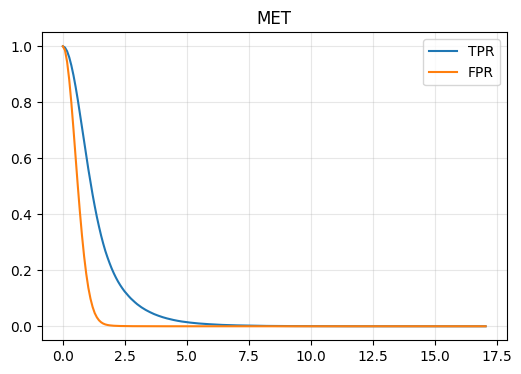

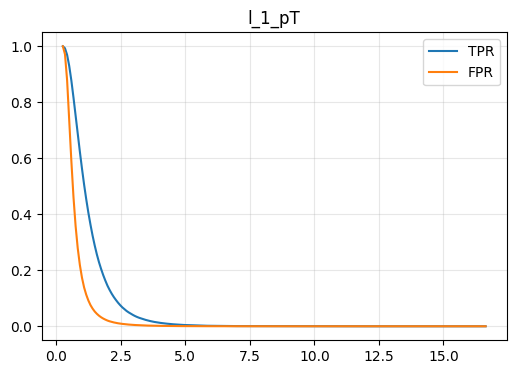

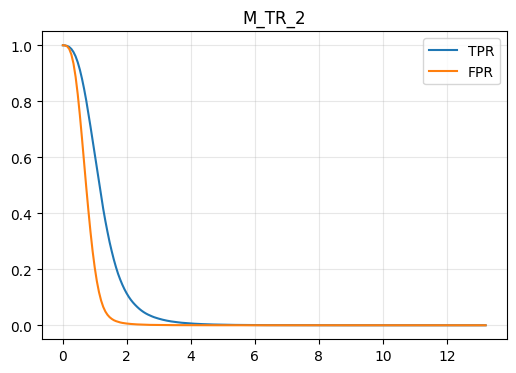

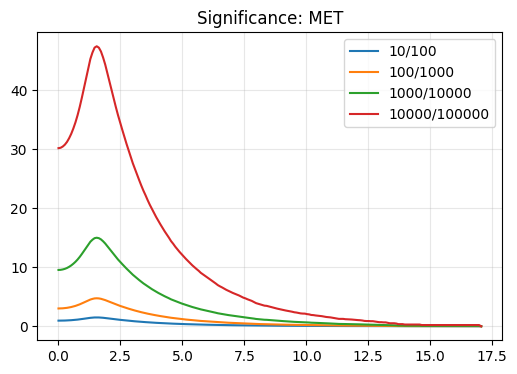

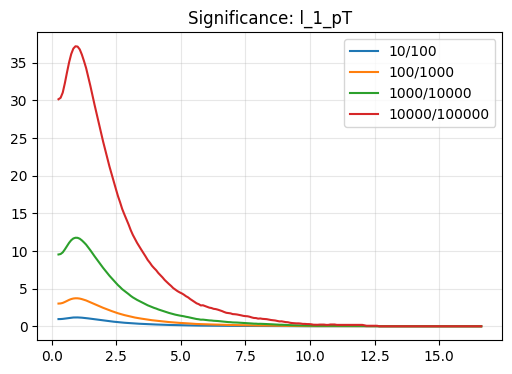

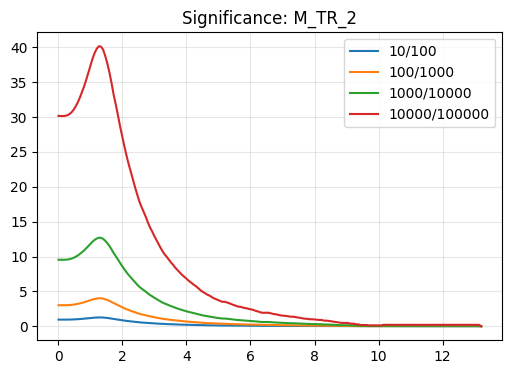

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# simply the helpers
def efficiencies(x_sig, x_bkg, mode, xc, mu=None):
    if mode == "gt":
        sig_pass = x_sig > xc
        bkg_pass = x_bkg > xc
    elif mode == "lt":
        sig_pass = x_sig < xc
        bkg_pass = x_bkg < xc
    elif mode == "abs_gt":
        sig_pass = np.abs(x_sig - mu) > xc
        bkg_pass = np.abs(x_bkg - mu) > xc
    elif mode == "abs_lt":
        sig_pass = np.abs(x_sig - mu) < xc
        bkg_pass = np.abs(x_bkg - mu) < xc

    return np.mean(sig_pass), np.mean(bkg_pass)

def significance(tpr, fpr, NS, NB):
    NS_p = tpr * NS
    NB_p = fpr * NB
    denom = np.sqrt(NS_p + NB_p)
    return np.divide(NS_p, denom, out=np.zeros_like(NS_p), where=denom > 0)

def scan_variable(df_sig, df_bkg, var, ncuts=200):
    x_sig = df_sig[var].values
    x_bkg = df_bkg[var].values

    xmin, xmax = min(x_sig.min(), x_bkg.min()), max(x_sig.max(), x_bkg.max())
    mu = np.mean(np.concatenate([x_sig, x_bkg]))

    xcs = np.linspace(xmin, xmax, ncuts)
    results = []

    for mode in ["gt", "lt"]:
        for xc in xcs:
            tpr, fpr = efficiencies(x_sig, x_bkg, mode, xc)
            results.append([mode, xc, tpr, fpr])

    abs_max = max(np.max(np.abs(x_sig - mu)), np.max(np.abs(x_bkg - mu)))
    abs_xcs = np.linspace(0, abs_max, ncuts)

    for mode in ["abs_gt", "abs_lt"]:
        for xc in abs_xcs:
            tpr, fpr = efficiencies(x_sig, x_bkg, mode, xc, mu)
            results.append([mode, xc, tpr, fpr])

    df = pd.DataFrame(results, columns=["mode", "xc", "TPR", "FPR"])
    df["score"] = df["TPR"] - df["FPR"]

    best = df.loc[df["score"].idxmax()]
    return df, best, mu

# 5.1
best_cuts = []

for var in VarNames[1:]:
    _, best, mu = scan_variable(df_sig, df_bkg, var)
    best_cuts.append([var, best["mode"], best["xc"], best["TPR"], best["FPR"], best["score"], mu])

best_cuts = pd.DataFrame(best_cuts,
    columns=["var", "mode", "xc", "TPR", "FPR", "score", "mu"]
)

print("Top variables by separation:\n")
display(best_cuts.sort_values("score", ascending=False).head(10))

# 5.2
def plot_tpr_fpr(var, mode, mu):
    x_sig = df_sig[var].values
    x_bkg = df_bkg[var].values

    xmin, xmax = min(x_sig.min(), x_bkg.min()), max(x_sig.max(), x_bkg.max())
    xcs = np.linspace(xmin, xmax, 200)

    tprs, fprs = [], []

    for xc in xcs:
        tpr, fpr = efficiencies(x_sig, x_bkg, mode, xc, mu)
        tprs.append(tpr)
        fprs.append(fpr)

    plt.figure(figsize=(6,4))
    plt.plot(xcs, tprs, label="TPR")
    plt.plot(xcs, fprs, label="FPR")
    plt.title(var)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

top3 = best_cuts.sort_values("score", ascending=False).head(3)

for _, row in top3.iterrows():
    plot_tpr_fpr(row["var"], row["mode"], row["mu"])

# 5.3
scenarios = [(10,100),(100,1000),(1000,10000),(10000,100000)]

def plot_significance(var, mode, mu):
    x_sig = df_sig[var].values
    x_bkg = df_bkg[var].values

    xmin, xmax = min(x_sig.min(), x_bkg.min()), max(x_sig.max(), x_bkg.max())
    xcs = np.linspace(xmin, xmax, 200)

    tprs, fprs = [], []

    for xc in xcs:
        tpr, fpr = efficiencies(x_sig, x_bkg, mode, xc, mu)
        tprs.append(tpr)
        fprs.append(fpr)

    tprs, fprs = np.array(tprs), np.array(fprs)

    plt.figure(figsize=(6,4))
    for NS, NB in scenarios:
        sig = significance(tprs, fprs, NS, NB)
        plt.plot(xcs, sig, label=f"{NS}/{NB}")

    plt.title(f"Significance: {var}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

for _, row in top3.iterrows():
    plot_significance(row["var"], row["mode"], row["mu"])

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [79]:
import pandas as pd
import numpy as np

# hamburger helper
def apply_cut(df, var, mode, xc, mu):
    if mode == "gt":
        return df[df[var] > xc]
    elif mode == "lt":
        return df[df[var] < xc]
    elif mode == "abs_gt":
        return df[np.abs(df[var] - mu) > xc]
    elif mode == "abs_lt":
        return df[np.abs(df[var] - mu) < xc]

def significance(NS, NB):
    return NS / np.sqrt(NS + NB) if (NS + NB) > 0 else 0

# 6.1
chosen = best_cuts.sort_values("score", ascending=False).head(3)
print("Chosen variables:")
display(chosen)

# 6.2
NS, NB = 1000, 10000 

rows = []
cur_sig = df_sig.copy()
cur_bkg = df_bkg.copy()

rows.append(["start", 1.0, 1.0, NS, NB, significance(NS, NB)])

for _, r in chosen.iterrows():
    cur_sig = apply_cut(cur_sig, r["var"], r["mode"], r["xc"], r["mu"])
    cur_bkg = apply_cut(cur_bkg, r["var"], r["mode"], r["xc"], r["mu"])

    eps_s = len(cur_sig) / len(df_sig)
    eps_b = len(cur_bkg) / len(df_bkg)

    NS_p = eps_s * NS
    NB_p = eps_b * NB

    rows.append([r["var"], eps_s, eps_b, NS_p, NB_p, significance(NS_p, NB_p)])

cutflow_df = pd.DataFrame(rows, columns=["cut", "eps_s", "eps_b", "NS", "NB", "sigma"])

print("\nCut Flow Table:\n")
display(cutflow_df)

# 6.3
print("""Changing cut order matters because variables are correlated.
Applying one cut changes the distribution of the next variable,
so the optimal threshold shifts. Strongly correlated variables
give diminishing returns when used together.""")

Chosen variables:


,var,mode,xc,TPR,FPR,score,mu
6,MET,gt,1.029118,0.560981,0.137275,0.423705,1.001159
0,l_1_pT,gt,0.831577,0.687723,0.278953,0.408769,1.000488
11,M_TR_2,gt,1.003817,0.610138,0.206545,0.403593,0.999876



Cut Flow Table:



,cut,eps_s,eps_b,NS,NB,sigma
0,start,1.000000,1.000000,1000.000000,10000.000000,9.534626
1,MET,0.560981,0.137275,560.980610,1372.753966,12.757025
2,l_1_pT,0.416088,0.050278,416.087592,502.779265,13.726458
3,M_TR_2,0.379214,0.049218,379.214378,492.179276,12.846286


Changing cut order matters because variables are correlated.
Applying one cut changes the distribution of the next variable,
so the optimal threshold shifts. Strongly correlated variables
give diminishing returns when used together.


## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



Top 3 variables:


,var,mode,xc,score
6,MET,gt,1.029118,0.423705
0,l_1_pT,gt,0.831577,0.408769
11,M_TR_2,gt,1.003817,0.403593


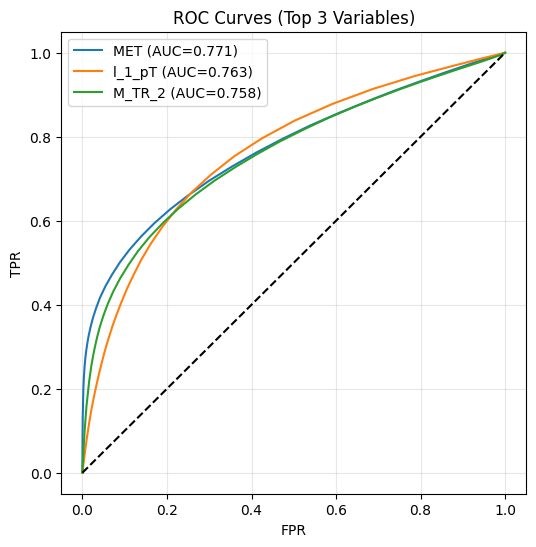

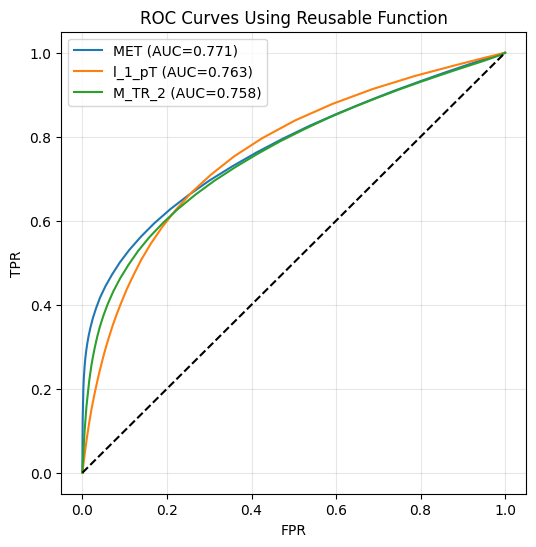

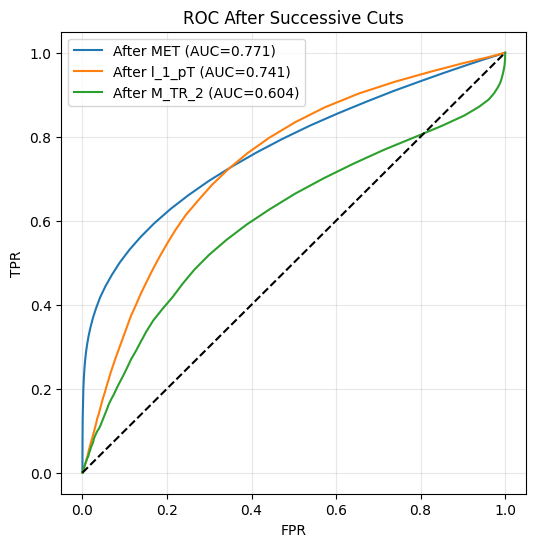

Order 1: ['MET', 'l_1_pT', 'M_TR_2']
Order 2: ['M_TR_2', 'l_1_pT', 'MET']


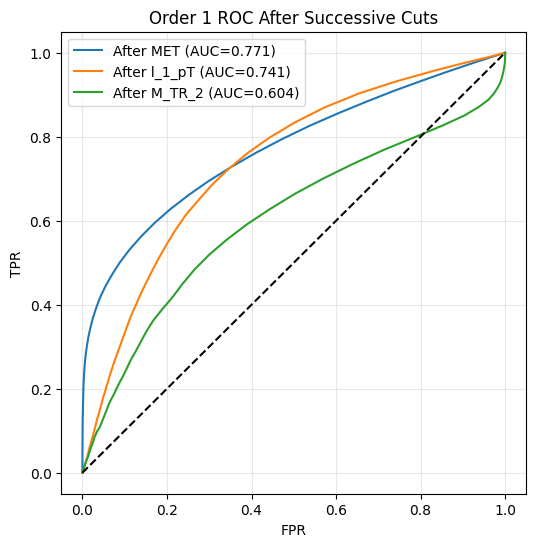

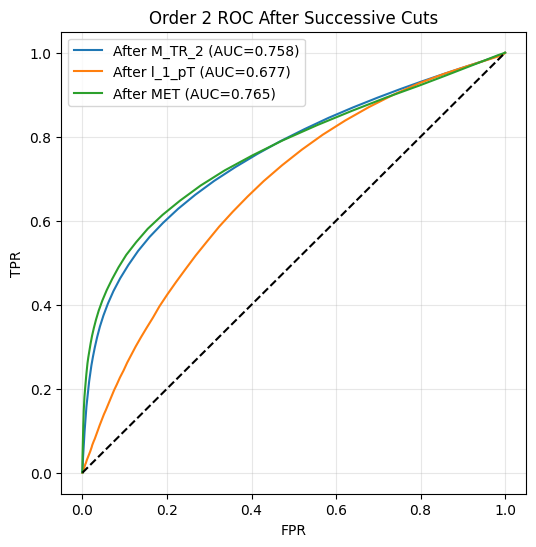

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

VarNames = [
    "signal",
    "l_1_pT",
    "l_1_eta",
    "l_1_phi",
    "l_2_pT",
    "l_2_eta",
    "l_2_phi",
    "MET",
    "MET_phi",
    "MET_rel",
    "axial_MET",
    "M_R",
    "M_TR_2",
    "R",
    "MT2",
    "S_R",
    "M_Delta_R",
    "dPhi_r_b",
    "cos_theta_r1"
]

try:
    df
except NameError:
    filename = "SUSY-small.csv"   
    df = pd.read_csv(filename, header=None, usecols=range(19))
    df.columns = VarNames

if list(df.columns) != VarNames:
    df = df.iloc[:, :19].copy()
    df.columns = VarNames

df_sig = df[df["signal"] == 1].copy()
df_bkg = df[df["signal"] == 0].copy()

def efficiencies(x_sig, x_bkg, mode, xc):
    if mode == "gt":
        sig_pass = x_sig > xc
        bkg_pass = x_bkg > xc
    elif mode == "lt":
        sig_pass = x_sig < xc
        bkg_pass = x_bkg < xc
    else:
        raise ValueError("mode must be 'gt' or 'lt'")
    return np.mean(sig_pass), np.mean(bkg_pass)

def scan_variable(df_sig, df_bkg, var, ncuts=200):
    x_sig = df_sig[var].values
    x_bkg = df_bkg[var].values

    xmin = min(x_sig.min(), x_bkg.min())
    xmax = max(x_sig.max(), x_bkg.max())
    xcs = np.linspace(xmin, xmax, ncuts)

    best_score = -1
    best_mode = None
    best_xc = None

    for mode in ["gt", "lt"]:
        for xc in xcs:
            tpr, fpr = efficiencies(x_sig, x_bkg, mode, xc)
            score = tpr - fpr
            if score > best_score:
                best_score = score
                best_mode = mode
                best_xc = xc

    return best_mode, best_xc, best_score

def compute_roc(df_sig, df_bkg, var, mode, ncuts=300):
    x_sig = df_sig[var].values
    x_bkg = df_bkg[var].values

    xmin = min(x_sig.min(), x_bkg.min())
    xmax = max(x_sig.max(), x_bkg.max())
    xcs = np.linspace(xmin, xmax, ncuts)

    tprs = []
    fprs = []

    for xc in xcs:
        tpr, fpr = efficiencies(x_sig, x_bkg, mode, xc)
        tprs.append(tpr)
        fprs.append(fpr)

    fpr = np.array(fprs)
    tpr = np.array(tprs)

    order = np.argsort(fpr)
    return fpr[order], tpr[order]

def auc(fpr, tpr):
    return np.trapezoid(tpr, fpr)

def apply_cut(df_in, var, mode, xc):
    if mode == "gt":
        return df_in[df_in[var] > xc].copy()
    elif mode == "lt":
        return df_in[df_in[var] < xc].copy()
    else:
        raise ValueError("mode must be 'gt' or 'lt'")

def plot_roc_set(df_sig, df_bkg, variables, best_cuts, title):
    plt.figure(figsize=(6, 6))
    for var in variables:
        row = best_cuts[best_cuts["var"] == var].iloc[0]
        fpr, tpr = compute_roc(df_sig, df_bkg, var, row["mode"])
        area = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{var} (AUC={area:.3f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

best_rows = []
for var in VarNames[1:]:
    mode, xc, score = scan_variable(df_sig, df_bkg, var)
    best_rows.append([var, mode, xc, score])

best_cuts = pd.DataFrame(best_rows, columns=["var", "mode", "xc", "score"])
top3 = best_cuts.sort_values("score", ascending=False).head(3)

print("Top 3 variables:")
display(top3)

plt.figure(figsize=(6, 6))

for _, row in top3.iterrows():
    fpr, tpr = compute_roc(df_sig, df_bkg, row["var"], row["mode"])
    area = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{row['var']} (AUC={area:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curves (Top 3 Variables)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plot_roc_set(
    df_sig,
    df_bkg,
    list(top3["var"]),
    best_cuts,
    "ROC Curves Using Reusable Function"
)

cur_sig = df_sig.copy()
cur_bkg = df_bkg.copy()

plt.figure(figsize=(6, 6))

for _, row in top3.iterrows():
    fpr, tpr = compute_roc(cur_sig, cur_bkg, row["var"], row["mode"])
    area = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"After {row['var']} (AUC={area:.3f})")

    cur_sig = apply_cut(cur_sig, row["var"], row["mode"], row["xc"])
    cur_bkg = apply_cut(cur_bkg, row["var"], row["mode"], row["xc"])

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC After Successive Cuts")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

order1 = list(top3["var"])
order2 = order1[::-1]

print("Order 1:", order1)
print("Order 2:", order2)

def roc_after_order(df_sig, df_bkg, ordered_vars, best_cuts, title):
    cur_sig = df_sig.copy()
    cur_bkg = df_bkg.copy()

    plt.figure(figsize=(6, 6))

    for var in ordered_vars:
        row = best_cuts[best_cuts["var"] == var].iloc[0]
        fpr, tpr = compute_roc(cur_sig, cur_bkg, var, row["mode"])
        area = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"After {var} (AUC={area:.3f})")

        cur_sig = apply_cut(cur_sig, var, row["mode"], row["xc"])
        cur_bkg = apply_cut(cur_bkg, var, row["mode"], row["xc"])

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

roc_after_order(df_sig, df_bkg, order1, best_cuts, "Order 1 ROC After Successive Cuts")
roc_after_order(df_sig, df_bkg, order2, best_cuts, "Order 2 ROC After Successive Cuts")

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

SB shape: (10, 10)
SW shape: (10, 10)


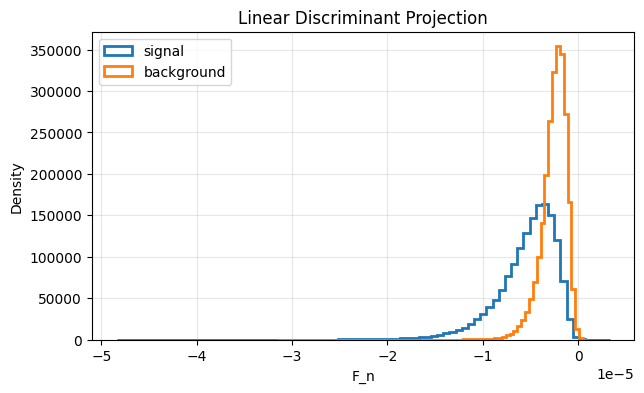

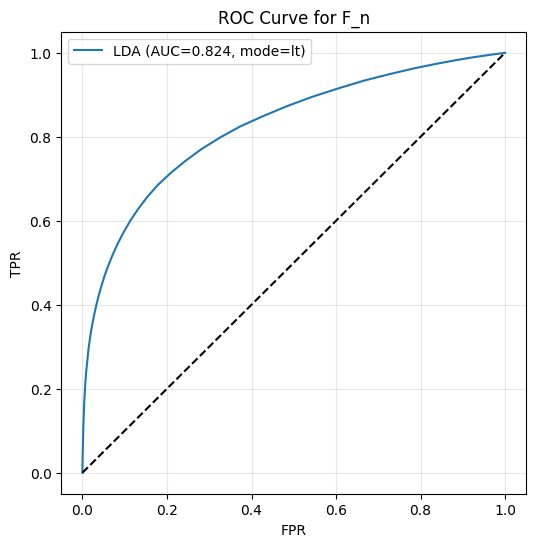

Maximum significance values:

NS=10, NB=100 -> max sigma = 1.488
NS=100, NB=1000 -> max sigma = 4.705
NS=1000, NB=10000 -> max sigma = 14.879
NS=10000, NB=100000 -> max sigma = 47.051


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

VarNames = [
    "signal",
    "l_1_pT",
    "l_1_eta",
    "l_1_phi",
    "l_2_pT",
    "l_2_eta",
    "l_2_phi",
    "MET",
    "MET_phi",
    "MET_rel",
    "axial_MET",
    "M_R",
    "M_TR_2",
    "R",
    "MT2",
    "S_R",
    "M_Delta_R",
    "dPhi_r_b",
    "cos_theta_r1"
]

FeatureNames = [
    "MET_rel",
    "axial_MET",
    "M_R",
    "M_TR_2",
    "R",
    "MT2",
    "S_R",
    "M_Delta_R",
    "dPhi_r_b",
    "cos_theta_r1"
]

try:
    df
except NameError:
    filename = "SUSY-small.csv"
    df = pd.read_csv(filename, header=None, usecols=range(19))
    df.columns = VarNames

if list(df.columns) != VarNames:
    df = df.iloc[:, :19].copy()
    df.columns = VarNames

df_sig = df[df["signal"] == 1].copy()
df_bkg = df[df["signal"] == 0].copy()

X_sig = df_sig[FeatureNames].values
X_bkg = df_bkg[FeatureNames].values

m1 = np.mean(X_sig, axis=0)
m2 = np.mean(X_bkg, axis=0)

SB = np.outer(m2 - m1, m2 - m1)

SW = np.zeros((X_sig.shape[1], X_sig.shape[1]))

for x in X_sig:
    d = (x - m1).reshape(-1, 1)
    SW += d @ d.T

for x in X_bkg:
    d = (x - m2).reshape(-1, 1)
    SW += d @ d.T

print("SB shape:", SB.shape)
print("SW shape:", SW.shape)

w = np.linalg.pinv(SW) @ (m2 - m1)

F_sig = X_sig @ w
F_bkg = X_bkg @ w

plt.figure(figsize=(7, 4))
plt.hist(F_sig, bins=80, density=True, histtype="step", linewidth=2, label="signal")
plt.hist(F_bkg, bins=80, density=True, histtype="step", linewidth=2, label="background")
plt.xlabel("F_n")
plt.ylabel("Density")
plt.title("Linear Discriminant Projection")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

def compute_roc_1d(sig_vals, bkg_vals, ncuts=300):
    xmin = min(sig_vals.min(), bkg_vals.min())
    xmax = max(sig_vals.max(), bkg_vals.max())
    cuts = np.linspace(xmin, xmax, ncuts)

    tprs_gt, fprs_gt = [], []
    tprs_lt, fprs_lt = [], []

    for c in cuts:
        tprs_gt.append(np.mean(sig_vals > c))
        fprs_gt.append(np.mean(bkg_vals > c))

        tprs_lt.append(np.mean(sig_vals < c))
        fprs_lt.append(np.mean(bkg_vals < c))

    fprs_gt = np.array(fprs_gt)
    tprs_gt = np.array(tprs_gt)
    fprs_lt = np.array(fprs_lt)
    tprs_lt = np.array(tprs_lt)

    auc_gt = np.trapezoid(tprs_gt[np.argsort(fprs_gt)], np.sort(fprs_gt))
    auc_lt = np.trapezoid(tprs_lt[np.argsort(fprs_lt)], np.sort(fprs_lt))

    if auc_gt >= auc_lt:
        order = np.argsort(fprs_gt)
        return cuts, fprs_gt[order], tprs_gt[order], "gt"
    else:
        order = np.argsort(fprs_lt)
        return cuts, fprs_lt[order], tprs_lt[order], "lt"

cuts, fpr, tpr, best_mode = compute_roc_1d(F_sig, F_bkg)

auc_val = np.trapezoid(tpr, fpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"LDA (AUC={auc_val:.3f}, mode={best_mode})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve for F_n")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

scenarios = [
    (10, 100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000)
]

print("Maximum significance values:\n")

for NS, NB in scenarios:
    sigmas = []
    for tp, fp in zip(tpr, fpr):
        NS_p = tp * NS
        NB_p = fp * NB
        if NS_p + NB_p > 0:
            sigma = NS_p / np.sqrt(NS_p + NB_p)
        else:
            sigma = 0
        sigmas.append(sigma)

    sigmas = np.array(sigmas)
    print(f"NS={NS}, NB={NB} -> max sigma = {sigmas.max():.3f}")